<a href="https://colab.research.google.com/github/Dhanush7-tech/Deep-Learning-LAB/blob/main/Lab-6/DeepLearning_Lab_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import io
import shutil
import zipfile
import urllib.request
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

DATA_DIR = "data"
DATASET_DIR = None  # set automatically by find_dataset_dir() below

DATASET_URLS = [
    "https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip",
    "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip",
]

SIGNAL_NAMES = [
    "body_acc_x", "body_acc_y", "body_acc_z",
    "body_gyro_x", "body_gyro_y", "body_gyro_z",
    "total_acc_x", "total_acc_y", "total_acc_z",
]  # 9 channels -> F = 9

TIME_STEPS = 128   # T
N_FEATURES = 9     # F
N_CLASSES = 6

TRAIN_FRAC, VAL_FRAC, TEST_FRAC = 0.70, 0.15, 0.15
SUBSET_SIZE = 3000   # set to None to use the full partition
RANDOM_STATE = 42

ACTIVITY_NAMES = {
    1: "WALKING", 2: "WALKING_UPSTAIRS", 3: "WALKING_DOWNSTAIRS",
    4: "SITTING", 5: "STANDING", 6: "LAYING",
}


def _extract_nested_zips(root):
    """Recursively extract any .zip files found inside root, since some
    mirrors package the data as a zip nested inside the outer zip."""
    changed = True
    while changed:
        changed = False
        for dirpath, _, filenames in os.walk(root):
            for fname in filenames:
                if fname.lower().endswith(".zip"):
                    fpath = os.path.join(dirpath, fname)
                    print(f"Extracting nested zip: {fpath}")
                    with zipfile.ZipFile(fpath) as zf:
                        zf.extractall(dirpath)
                    os.remove(fpath)
                    changed = True


def download_dataset(force=False):
    """Download + fully extract the UCI HAR Dataset (handles zips nested
    inside zips). Set force=True to wipe any stale/partial 'data' folder
    and re-download from scratch."""
    if force:
        shutil.rmtree(DATA_DIR, ignore_errors=True)

    need_download = not (os.path.isdir(DATA_DIR) and os.listdir(DATA_DIR))
    if need_download:
        os.makedirs(DATA_DIR, exist_ok=True)
        last_err = None
        downloaded = False
        for url in DATASET_URLS:
            try:
                print(f"Downloading dataset from {url} ...")
                with urllib.request.urlopen(url, timeout=60) as resp:
                    raw = resp.read()
                with zipfile.ZipFile(io.BytesIO(raw)) as zf:
                    zf.extractall(DATA_DIR)
                print("Download and extraction complete.")
                downloaded = True
                break
            except Exception as e:
                print(f"  failed: {e}")
                last_err = e
        if not downloaded:
            raise RuntimeError(
                "Could not download the UCI HAR Dataset automatically "
                f"(last error: {last_err}). Download it manually from "
                "https://archive.ics.uci.edu/dataset/240/human+activity+recognition+using+smartphones "
                f"and place the extracted folder inside '{DATA_DIR}/'."
            )
    else:
        print(f"'{DATA_DIR}' already has content, checking for nested zips.")

    # Always sweep for nested zips (covers both fresh downloads and
    # previously-downloaded-but-not-fully-extracted folders).
    _extract_nested_zips(DATA_DIR)


def find_dataset_dir(root="data"):
    """Walk the extracted files to find the real dataset folder, whatever
    it's actually named/nested as."""
    for dirpath, dirnames, filenames in os.walk(root):
        if os.path.basename(dirpath) == "train" and "Inertial Signals" in dirnames:
            return os.path.dirname(dirpath)
    raise FileNotFoundError(
        f"Could not locate the dataset's 'train' folder under '{root}'. "
        f"Top-level contents: {os.listdir(root)}"
    )


# --- 3. Load raw inertial signals -> X in R^{N x 128 x 9} ---
def load_raw_partition(partition):
    signals_dir = os.path.join(DATASET_DIR, partition, "Inertial Signals")
    channels = [
        np.loadtxt(os.path.join(signals_dir, f"{name}_{partition}.txt"))
        for name in SIGNAL_NAMES
    ]                                   # each (N, 128)
    X = np.stack(channels, axis=-1)     # (N, 128, 9)
    y = np.loadtxt(os.path.join(DATASET_DIR, partition, f"y_{partition}.txt")).astype(int)
    return X, y


def stratified_subset(X, y, subset_size, random_state=RANDOM_STATE):
    if subset_size is None or subset_size >= len(y):
        return X, y
    frac = subset_size / len(y)
    X_sub, _, y_sub, _ = train_test_split(
        X, y, train_size=frac, stratify=y, random_state=random_state
    )
    return X_sub, y_sub


def print_class_distribution(y, label_names, title):
    print(f"\nClass distribution -- {title}")
    total = len(y)
    for cls in sorted(label_names):
        count = int(np.sum(y == cls))
        pct = 100.0 * count / total if total else 0.0
        print(f"  {label_names[cls]:<20s}: {count:5d}  ({pct:5.1f}%)")


# --- 5. Preprocessing: encode, split, normalize, verify ---
def preprocess(X_raw, y_raw):
    encoder = LabelEncoder()
    encoder.fit(sorted(ACTIVITY_NAMES.keys()))
    y_encoded = encoder.transform(y_raw)

    X_train, X_temp, y_train, y_temp = train_test_split(
        X_raw, y_encoded, train_size=TRAIN_FRAC,
        stratify=y_encoded, random_state=RANDOM_STATE,
    )
    val_ratio = VAL_FRAC / (VAL_FRAC + TEST_FRAC)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, train_size=val_ratio,
        stratify=y_temp, random_state=RANDOM_STATE,
    )

    mean = X_train.reshape(-1, N_FEATURES).mean(axis=0)
    std = X_train.reshape(-1, N_FEATURES).std(axis=0)
    std[std == 0] = 1e-8

    normalize = lambda X: (X - mean) / std
    X_train, X_val, X_test = normalize(X_train), normalize(X_val), normalize(X_test)

    names_by_code = {i: ACTIVITY_NAMES[k] for i, k in enumerate(sorted(ACTIVITY_NAMES.keys()))}
    print_class_distribution(y_train, names_by_code, "Train")
    print_class_distribution(y_val, names_by_code, "Validation")
    print_class_distribution(y_test, names_by_code, "Test")

    print("\nInput tensor shape:")
    print(f"  Training   : {X_train.shape}")
    print(f"  Validation : {X_val.shape}")
    print(f"  Testing    : {X_test.shape}")
    print(f"Number of classes: {N_CLASSES}")
    print(f"Number of features per time step: {N_FEATURES}")
    print(f"Sequence length: {TIME_STEPS}")

    return (X_train, y_train), (X_val, y_val), (X_test, y_test), (mean, std)


if __name__ == "__main__":
    download_dataset(force=True)   # force=True clears any stale 'data' folder
    DATASET_DIR = find_dataset_dir(DATA_DIR)
    print(f"Using dataset dir: {DATASET_DIR}")

    X_train_full, y_train_full = load_raw_partition("train")
    X_test_full, y_test_full = load_raw_partition("test")
    print(f"Full train partition: X={X_train_full.shape}, y={y_train_full.shape}")
    print(f"Full test partition : X={X_test_full.shape}, y={y_test_full.shape}")

    X_pool = np.concatenate([X_train_full, X_test_full], axis=0)
    y_pool = np.concatenate([y_train_full, y_test_full], axis=0)
    X_pool, y_pool = stratified_subset(X_pool, y_pool, SUBSET_SIZE)

    (X_train, y_train), (X_val, y_val), (X_test, y_test), (mean, std) = preprocess(X_pool, y_pool)

Download and extraction complete.
Extracting nested zip: data/UCI HAR Dataset.zip
Using dataset dir: data/UCI HAR Dataset
Full train partition: X=(7352, 128, 9), y=(7352,)
Full test partition : X=(2947, 128, 9), y=(2947,)

Class distribution -- Train
  WALKING             :   351  ( 16.7%)
  WALKING_UPSTAIRS    :   315  ( 15.0%)
  WALKING_DOWNSTAIRS  :   286  ( 13.6%)
  SITTING             :   363  ( 17.3%)
  STANDING            :   389  ( 18.5%)
  LAYING              :   396  ( 18.9%)

Class distribution -- Validation
  WALKING             :    76  ( 16.9%)
  WALKING_UPSTAIRS    :    68  ( 15.1%)
  WALKING_DOWNSTAIRS  :    61  ( 13.6%)
  SITTING             :    77  ( 17.1%)
  STANDING            :    83  ( 18.4%)
  LAYING              :    85  ( 18.9%)

Class distribution -- Test
  WALKING             :    75  ( 16.7%)
  WALKING_UPSTAIRS    :    67  ( 14.9%)
  WALKING_DOWNSTAIRS  :    62  ( 13.8%)
  SITTING             :    78  ( 17.3%)
  STANDING            :    83  ( 18.4%)
  LAYIN

Saved plot to temporal_signals.png


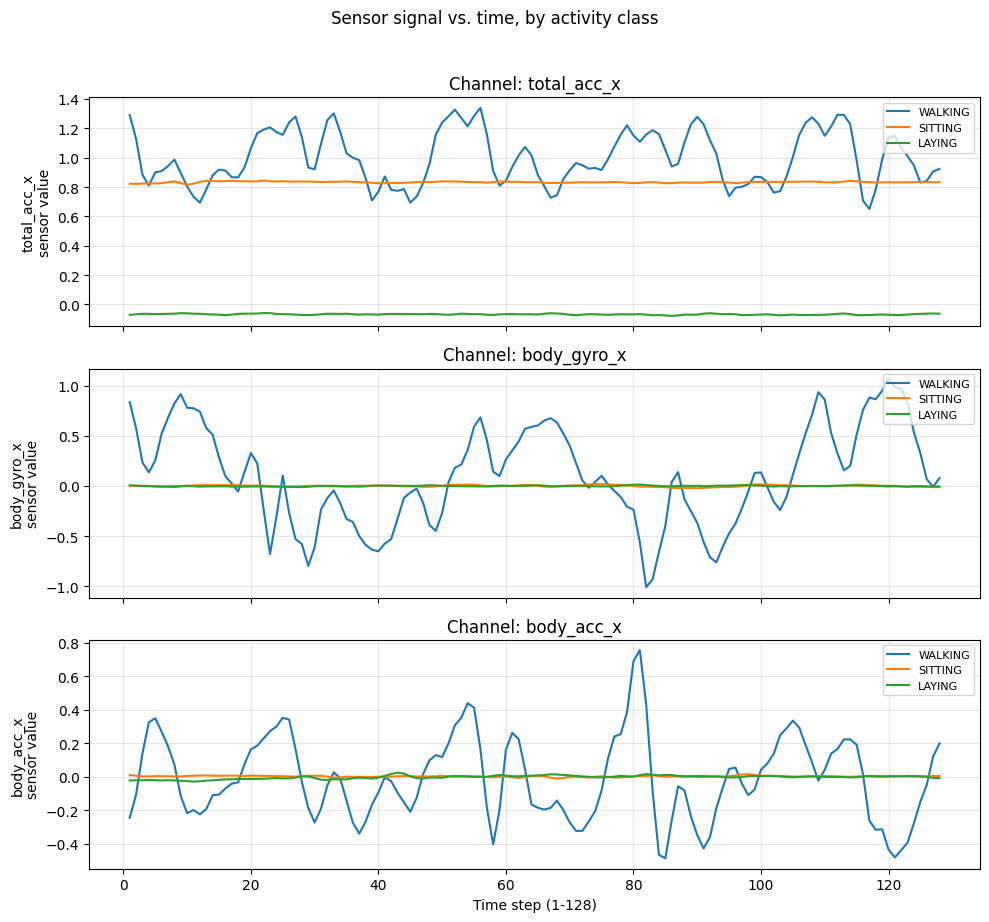

In [2]:
import numpy as np
import matplotlib.pyplot as plt

SIGNAL_NAMES = [
    "body_acc_x", "body_acc_y", "body_acc_z",
    "body_gyro_x", "body_gyro_y", "body_gyro_z",
    "total_acc_x", "total_acc_y", "total_acc_z",
]

ACTIVITY_NAMES = {
    1: "WALKING", 2: "WALKING_UPSTAIRS", 3: "WALKING_DOWNSTAIRS",
    4: "SITTING", 5: "STANDING", 6: "LAYING",
}


def plot_representative_sequences(X_pool, y_pool, activity_codes, channel_names, random_state=42):
    """
    X_pool : (N, 128, 9) RAW (unnormalized) windows -- use the pool BEFORE
             preprocess() splits/normalizes it, so values stay in their
             original physical units and are easier to read visually.
    y_pool : (N,) integer activity codes (1-6, per ACTIVITY_NAMES)
    activity_codes : list of >=3 activity codes to compare, e.g. [1, 4, 6]
    channel_names : list of >=3 channel names from SIGNAL_NAMES to plot
    """
    rng = np.random.default_rng(random_state)
    channel_idx = [SIGNAL_NAMES.index(name) for name in channel_names]
    time_steps = np.arange(1, X_pool.shape[1] + 1)  # 1..128

    fig, axes = plt.subplots(
        len(channel_names), 1, figsize=(10, 3 * len(channel_names)), sharex=True
    )
    if len(channel_names) == 1:
        axes = [axes]

    for row, (ch_i, ch_name) in enumerate(zip(channel_idx, channel_names)):
        ax = axes[row]
        for code in activity_codes:
            candidates = np.where(y_pool == code)[0]
            pick = rng.choice(candidates)  # one representative window for this class
            ax.plot(time_steps, X_pool[pick, :, ch_i], label=ACTIVITY_NAMES[code])
        ax.set_ylabel(f"{ch_name}\nsensor value")
        ax.set_title(f"Channel: {ch_name}")
        ax.legend(loc="upper right", fontsize=8)
        ax.grid(alpha=0.3)

    axes[-1].set_xlabel("Time step (1-128)")
    fig.suptitle("Sensor signal vs. time, by activity class", y=1.02)
    fig.tight_layout()
    plt.savefig("temporal_signals.png", dpi=150, bbox_inches="tight")
    print("Saved plot to temporal_signals.png")
    plt.show()


if __name__ == "__main__":
    # X_pool, y_pool should already exist from the preprocessing step
    # (the pool BEFORE preprocess() split/normalized it), e.g.:
    #   X_pool, y_pool = stratified_subset(X_pool, y_pool, SUBSET_SIZE)
    activity_codes = [1, 4, 6]       # WALKING, SITTING, LAYING -- dynamic vs static
    channel_names = ["total_acc_x", "body_gyro_x", "body_acc_x"]  # >= 3 channels

    plot_representative_sequences(X_pool, y_pool, activity_codes, channel_names)

**What temporal pattern is visible?**

 WALKING shows strong, roughly periodic oscillations (the repeating gait cycle shows up clearly in both acceleration and gyroscope channels), while SITTING and LAYING are nearly flat with only small, high-frequency noise fluctuations around a constant baseline — there's no periodicity because the body isn't moving.

**Which activities exhibit similar patterns?**

The three dynamic activities (WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS) look similar to each other — all periodic — differing mainly in amplitude and stride frequency (stairs tend to show larger vertical acceleration swings). Similarly, the static activities (SITTING, STANDING, LAYING) look similar to each other — all near-flat — and are distinguished mostly by the constant offset/orientation (e.g. gravity component on total_acc) rather than by shape.

**Why is the ordering of measurements important?**

The activity signature lives in how the signal evolves, not in any single reading — periodicity, rate of change, and phase relationships between channels (e.g. acceleration vs. gyroscope) are only visible when time steps are kept in sequence. Shuffling the 128 steps within a window would destroy the gait rhythm and make WALKING indistinguishable from noise, which is exactly why RNN/LSTM/GRU models (which process steps in order) can separate these classes far better than a model fed the same 128×9 values as an unordered feature bag.

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers

TIME_STEPS = 128
N_FEATURES = 9
N_CLASSES = 6

RECURRENT_UNITS = 32
DROPOUT_RATE = 0.2
DENSE_UNITS = 16
LEARNING_RATE = 1e-3
BATCH_SIZE = 32
EPOCHS = 30
RANDOM_STATE = 42


def build_rnn_model():
    """
    Input(128, 9) -> SimpleRNN(32) -> Dropout(0.2)
                   -> Dense(16, relu) -> Dense(6, softmax)
    """
    model = models.Sequential([
        layers.Input(shape=(TIME_STEPS, N_FEATURES)),
        layers.SimpleRNN(RECURRENT_UNITS, name="rnn"),
        layers.Dropout(DROPOUT_RATE),
        layers.Dense(DENSE_UNITS, activation="relu", name="dense_hidden"),
        layers.Dense(N_CLASSES, activation="softmax", name="output"),
    ], name="rnn_model")

    model.compile(
        optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def train_rnn(X_train, y_train, X_val, y_val, X_test, y_test):
    tf.random.set_seed(RANDOM_STATE)

    model = build_rnn_model()
    model.summary()

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=2,
    )

    test_loss, test_acc = model.evaluate(X_test, y_test, batch_size=BATCH_SIZE, verbose=0)
    print(f"\nRNN — test loss: {test_loss:.4f}, test accuracy: {test_acc:.4f}")

    return model, history.history, test_loss, test_acc


if __name__ == "__main__":
    # X_train, y_train, X_val, y_val, X_test, y_test should already exist
    # from the preprocessing step (normalized, split into train/val/test).
    rnn_model, rnn_history, rnn_test_loss, rnn_test_acc = train_rnn(
        X_train, y_train, X_val, y_val, X_test, y_test
    )

Model: "rnn_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rnn (SimpleRNN)                 │ (None, 32)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,974 (7.71 KB)

 Trainable params: 1,974 (7.71 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
66/66 - 6s - 93ms/step - accuracy: 0.4271 - loss: 1.5272 - val_accuracy: 0.5556 - val_loss: 1.2408
Epoch 2/30
66/66 - 1s - 12ms/step - accuracy: 0.5533 - loss: 1.1494 - val_accuracy: 0.6067 - val_loss: 1.0216
Epoch 3/30
66/66 - 1s - 12ms/step - accuracy: 0.6148 - loss: 0.9437 - val_accuracy: 0.6600 - val_loss: 0.8215
Epoch 4/30
66/66 - 1s - 13ms/step - accuracy: 0.6457 - loss: 0.8068 - val_accuracy: 0.6489 - val_loss: 0.7388
Epoch 5/30
66/66 - 1s - 13ms/step - accuracy: 0.6624 - loss: 0.7425 - val_accuracy: 0.6644 - val_loss: 0.7057
Epoch 6/30
66/66 - 1s - 17ms/step - accuracy: 0.6786 - loss: 0.6916 - val_accuracy: 0.6933 - val_loss: 0.6361
Epoch 7/30
66/66 - 1s - 10ms/step - accuracy: 0.6938 - loss: 0.6585 - val_accuracy: 0.7022 - val_loss: 0.6264
Epoch 8/30
66/66 - 1s - 10ms/step - accuracy: 0.7067 - loss: 0.6339 - val_accuracy: 0.7156 - val_loss: 0.6227
Epoch 9/30
66/66 - 1s - 11ms/step - accuracy: 0.7148 - loss: 0.6123 - val_accuracy: 0.7178 - val_loss: 0.6066
Epoch 10/3

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers

TIME_STEPS = 128
N_FEATURES = 9
N_CLASSES = 6

RECURRENT_UNITS = 32
DROPOUT_RATE = 0.2
DENSE_UNITS = 16
LEARNING_RATE = 1e-3
BATCH_SIZE = 32
EPOCHS = 30
RANDOM_STATE = 42


def build_model(recurrent_type):
    """
    Same classifier as the RNN, with only the recurrent layer swapped:
        Input(128, 9) -> [SimpleRNN|LSTM|GRU](32) -> Dropout(0.2)
                       -> Dense(16, relu) -> Dense(6, softmax)
    """
    recurrent_type = recurrent_type.lower()
    if recurrent_type == "rnn":
        recurrent_layer = layers.SimpleRNN(RECURRENT_UNITS, name="rnn")
    elif recurrent_type == "lstm":
        recurrent_layer = layers.LSTM(RECURRENT_UNITS, name="lstm")
    elif recurrent_type == "gru":
        recurrent_layer = layers.GRU(RECURRENT_UNITS, name="gru")
    else:
        raise ValueError(f"Unknown recurrent_type: {recurrent_type}")

    model = models.Sequential([
        layers.Input(shape=(TIME_STEPS, N_FEATURES)),
        recurrent_layer,
        layers.Dropout(DROPOUT_RATE),
        layers.Dense(DENSE_UNITS, activation="relu", name="dense_hidden"),
        layers.Dense(N_CLASSES, activation="softmax", name="output"),
    ], name=f"{recurrent_type}_model")

    model.compile(
        optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def train_model(recurrent_type, X_train, y_train, X_val, y_val, X_test, y_test):
    tf.random.set_seed(RANDOM_STATE)

    model = build_model(recurrent_type)
    model.summary()

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=2,
    )

    test_loss, test_acc = model.evaluate(X_test, y_test, batch_size=BATCH_SIZE, verbose=0)
    print(f"\n{recurrent_type.upper()} — test loss: {test_loss:.4f}, test accuracy: {test_acc:.4f}")

    return model, history.history, test_loss, test_acc


if __name__ == "__main__":
    # X_train, y_train, X_val, y_val, X_test, y_test already exist from preprocessing.
    lstm_model, lstm_history, lstm_test_loss, lstm_test_acc = train_model(
        "lstm", X_train, y_train, X_val, y_val, X_test, y_test
    )

    gru_model, gru_history, gru_test_loss, gru_test_acc = train_model(
        "gru", X_train, y_train, X_val, y_val, X_test, y_test
    )

    print("\n" + "=" * 50)
    print("Comparison (same input, output, optimizer, batch size)")
    print("=" * 50)
    print(f"{'Model':<8s}{'Test Loss':>12s}{'Test Accuracy':>16s}")
    print(f"{'LSTM':<8s}{lstm_test_loss:>12.4f}{lstm_test_acc:>16.4f}")
    print(f"{'GRU':<8s}{gru_test_loss:>12.4f}{gru_test_acc:>16.4f}")

Model: "lstm_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,006 (23.46 KB)

 Trainable params: 6,006 (23.46 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,758 (18.59 KB)

 Trainable params: 4,758 (18.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
66/66 - 3s - 39ms/step - accuracy: 0.3848 - loss: 1.6559 - val_accuracy: 0.5867 - val_loss: 1.4218
Epoch 2/30
66/66 - 1s - 11ms/step - accuracy: 0.5605 - loss: 1.2447 - val_accuracy: 0.6178 - val_loss: 1.0132
Epoch 3/30
66/66 - 1s - 10ms/step - accuracy: 0.6476 - loss: 0.8861 - val_accuracy: 0.6733 - val_loss: 0.7737
Epoch 4/30
66/66 - 1s - 10ms/step - accuracy: 0.6819 - loss: 0.7419 - val_accuracy: 0.7222 - val_loss: 0.6709
Epoch 5/30
66/66 - 1s - 10ms/step - accuracy: 0.7152 - loss: 0.6641 - val_accuracy: 0.7511 - val_loss: 0.6054
Epoch 6/30
66/66 - 1s - 10ms/step - accuracy: 0.7448 - loss: 0.6038 - val_accuracy: 0.7711 - val_loss: 0.5542
Epoch 7/30
66/66 - 1s - 10ms/step - accuracy: 0.7805 - loss: 0.5523 - val_accuracy: 0.8133 - val_loss: 0.4875
Epoch 8/30
66/66 - 1s - 10ms/step - accuracy: 0.8376 - loss: 0.4667 - val_accuracy: 0.8733 - val_loss: 0.3934
Epoch 9/30
66/66 - 1s - 10ms/step - accuracy: 0.8795 - loss: 0.3763 - val_accuracy: 0.9044 - val_loss: 0.2963
Epoch 10/3

Saved rnn_curves.png


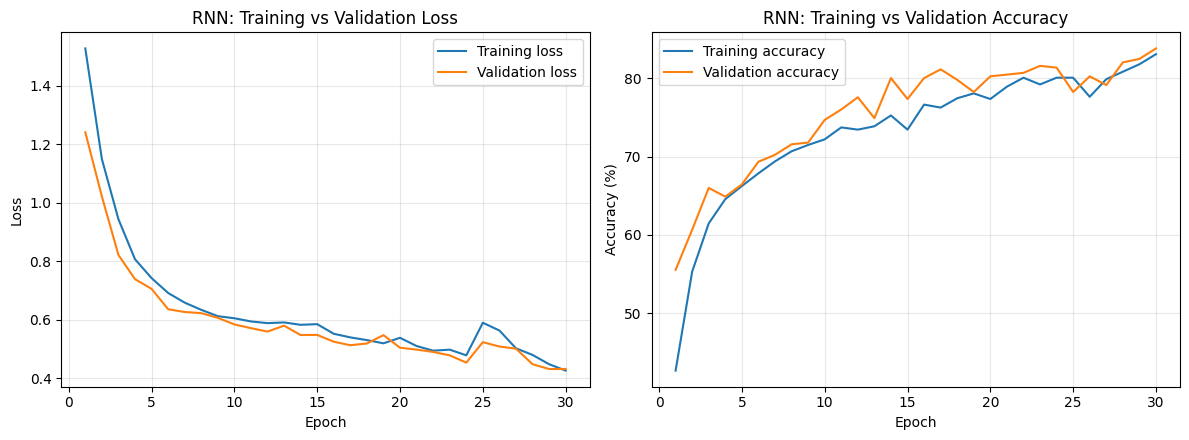

Saved lstm_curves.png


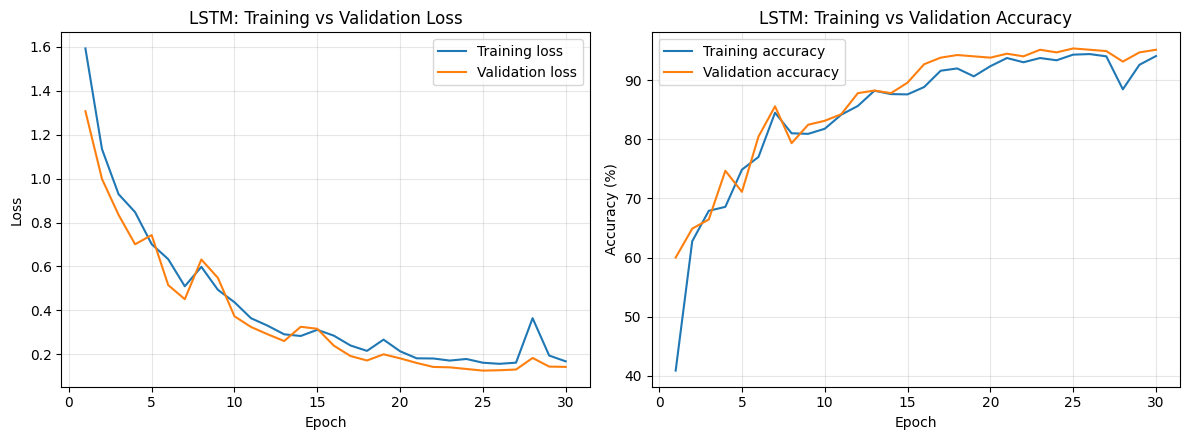

Saved gru_curves.png


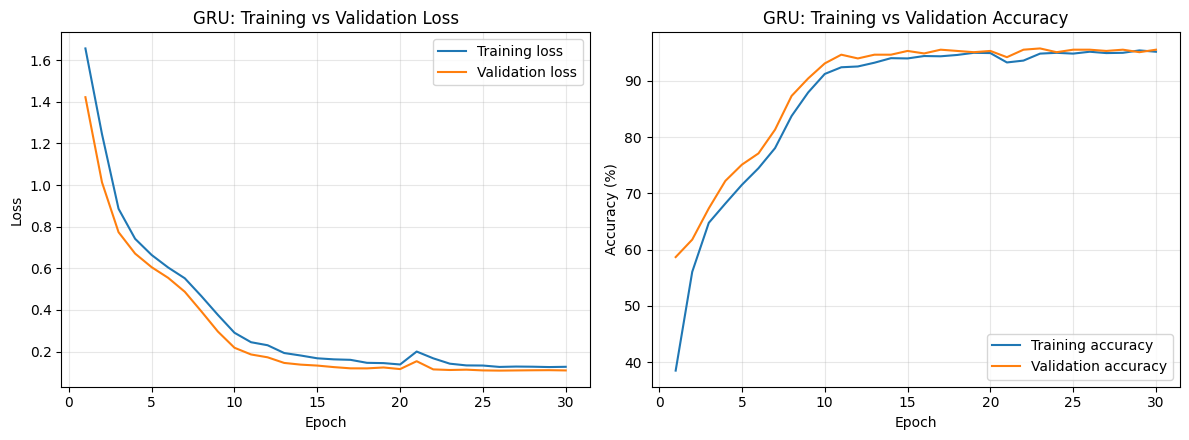

In [5]:
import matplotlib.pyplot as plt


def plot_training_curves(history, model_name):
    """
    history : the dict returned by model.fit(...).history
              (keys: 'loss', 'val_loss', 'accuracy', 'val_accuracy')
    model_name : string label used in titles/filenames, e.g. "RNN"

    Produces:
      Plot 2 - Training vs Validation Loss (epoch on x-axis)
      Plot 3 - Training vs Validation Accuracy in % (epoch on x-axis)
    """
    epochs = range(1, len(history["loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    # Plot 2: Loss
    axes[0].plot(epochs, history["loss"], label="Training loss")
    axes[0].plot(epochs, history["val_loss"], label="Validation loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title(f"{model_name}: Training vs Validation Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Plot 3: Accuracy (%)
    train_acc_pct = [a * 100 for a in history["accuracy"]]
    val_acc_pct = [a * 100 for a in history["val_accuracy"]]
    axes[1].plot(epochs, train_acc_pct, label="Training accuracy")
    axes[1].plot(epochs, val_acc_pct, label="Validation accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy (%)")
    axes[1].set_title(f"{model_name}: Training vs Validation Accuracy")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    fig.tight_layout()
    fname = f"{model_name.lower()}_curves.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    print(f"Saved {fname}")
    plt.show()


if __name__ == "__main__":
    # rnn_history, lstm_history, gru_history are the .history dicts
    # returned by model.fit() for each model (already in memory from
    # the earlier training steps).
    plot_training_curves(rnn_history, "RNN")
    plot_training_curves(lstm_history, "LSTM")
    plot_training_curves(gru_history, "GRU")

Epoch 1/30
66/66 - 6s - 88ms/step - accuracy: 0.3900 - loss: 1.5029 - val_accuracy: 0.5356 - val_loss: 1.1644
Epoch 2/30
66/66 - 1s - 12ms/step - accuracy: 0.5386 - loss: 1.0983 - val_accuracy: 0.5800 - val_loss: 1.0051
Epoch 3/30
66/66 - 1s - 11ms/step - accuracy: 0.5757 - loss: 0.9671 - val_accuracy: 0.6489 - val_loss: 0.8491
Epoch 4/30
66/66 - 1s - 11ms/step - accuracy: 0.6452 - loss: 0.8352 - val_accuracy: 0.6533 - val_loss: 0.7737
Epoch 5/30
66/66 - 1s - 11ms/step - accuracy: 0.6695 - loss: 0.7635 - val_accuracy: 0.6622 - val_loss: 0.7218
Epoch 6/30
66/66 - 1s - 11ms/step - accuracy: 0.6919 - loss: 0.7207 - val_accuracy: 0.6622 - val_loss: 0.7432
Epoch 7/30
66/66 - 1s - 11ms/step - accuracy: 0.6995 - loss: 0.6881 - val_accuracy: 0.6400 - val_loss: 0.8526
Epoch 8/30
66/66 - 1s - 11ms/step - accuracy: 0.7119 - loss: 0.6889 - val_accuracy: 0.6778 - val_loss: 0.6881
Epoch 9/30
66/66 - 1s - 10ms/step - accuracy: 0.7133 - loss: 0.6591 - val_accuracy: 0.7311 - val_loss: 0.6209
Epoch 10/3

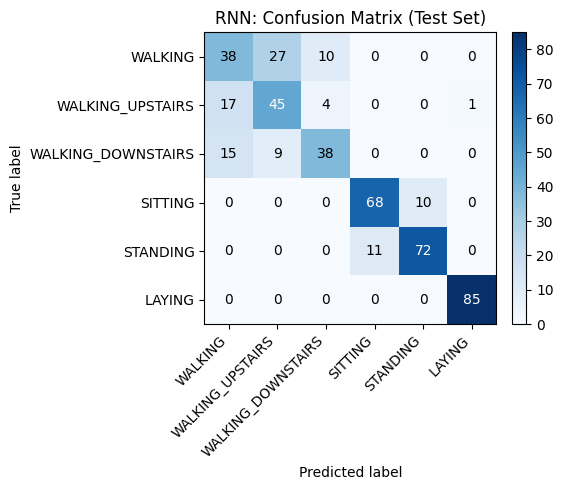

Saved lstm_confusion_matrix.png


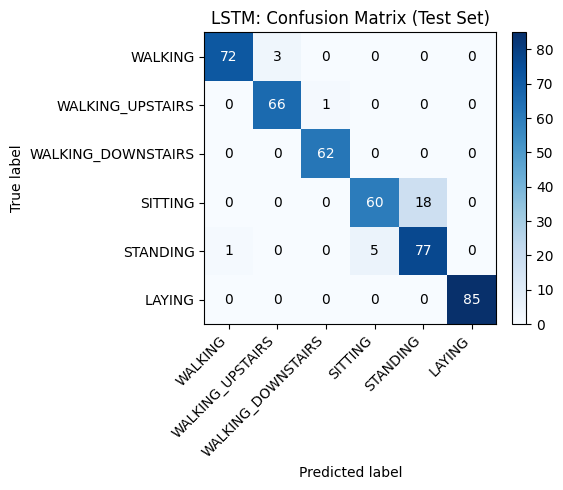

Saved gru_confusion_matrix.png


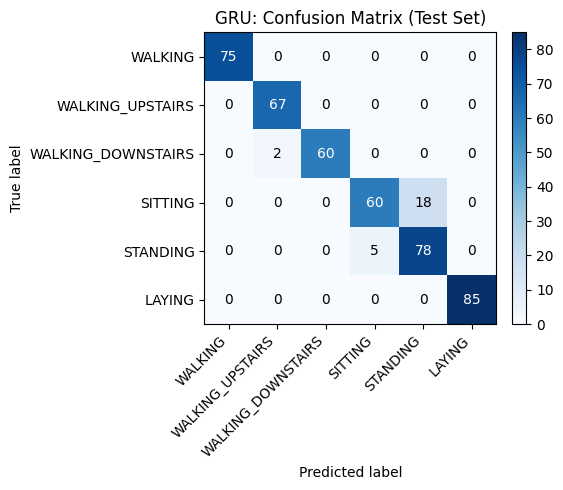

In [6]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, confusion_matrix
)

TIME_STEPS = 128
N_FEATURES = 9
N_CLASSES = 6

RECURRENT_UNITS = 32
DROPOUT_RATE = 0.2
DENSE_UNITS = 16
LEARNING_RATE = 1e-3
BATCH_SIZE = 32
EPOCHS = 30
RANDOM_STATE = 42

ACTIVITY_NAMES = {
    1: "WALKING", 2: "WALKING_UPSTAIRS", 3: "WALKING_DOWNSTAIRS",
    4: "SITTING", 5: "STANDING", 6: "LAYING",
}
CLASS_LABELS = [ACTIVITY_NAMES[k] for k in sorted(ACTIVITY_NAMES.keys())]  # index 0-5 order


def build_model(recurrent_type):
    recurrent_type = recurrent_type.lower()
    if recurrent_type == "rnn":
        recurrent_layer = layers.SimpleRNN(RECURRENT_UNITS, name="rnn")
    elif recurrent_type == "lstm":
        recurrent_layer = layers.LSTM(RECURRENT_UNITS, name="lstm")
    elif recurrent_type == "gru":
        recurrent_layer = layers.GRU(RECURRENT_UNITS, name="gru")
    else:
        raise ValueError(f"Unknown recurrent_type: {recurrent_type}")

    model = models.Sequential([
        layers.Input(shape=(TIME_STEPS, N_FEATURES)),
        recurrent_layer,
        layers.Dropout(DROPOUT_RATE),
        layers.Dense(DENSE_UNITS, activation="relu", name="dense_hidden"),
        layers.Dense(N_CLASSES, activation="softmax", name="output"),
    ], name=f"{recurrent_type}_model")

    model.compile(
        optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def train_and_evaluate(recurrent_type, X_train, y_train, X_val, y_val, X_test, y_test):
    """Trains one model, times training, and computes all mandatory
    performance-evaluation metrics on the independent test set."""
    tf.random.set_seed(RANDOM_STATE)

    model = build_model(recurrent_type)
    n_params = model.count_params()

    start_time = time.time()
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=2,
    )
    training_time = time.time() - start_time

    y_pred_probs = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="macro", zero_division=0
    )
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n{recurrent_type.upper()} — "
          f"Accuracy: {accuracy*100:.2f}%  "
          f"Macro-P: {precision*100:.2f}%  "
          f"Macro-R: {recall*100:.2f}%  "
          f"Macro-F1: {f1*100:.2f}%  "
          f"Params: {n_params}  "
          f"Time: {training_time:.1f}s")

    return {
        "model": model,
        "history": history.history,
        "y_pred": y_pred,
        "metrics": {
            "Model": recurrent_type.upper(),
            "Accuracy (%)": accuracy * 100,
            "Macro Precision (%)": precision * 100,
            "Macro Recall (%)": recall * 100,
            "Macro F1 (%)": f1 * 100,
            "Parameters": n_params,
            "Training Time (s)": training_time,
        },
        "confusion_matrix": cm,
    }


def plot_confusion_matrix(cm, model_name, class_labels=CLASS_LABELS):
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(class_labels)))
    ax.set_yticks(range(len(class_labels)))
    ax.set_xticklabels(class_labels, rotation=45, ha="right")
    ax.set_yticklabels(class_labels)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(f"{model_name}: Confusion Matrix (Test Set)")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black")

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    fname = f"{model_name.lower()}_confusion_matrix.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    print(f"Saved {fname}")
    plt.show()


if __name__ == "__main__":
    # X_train, y_train, X_val, y_val, X_test, y_test already exist from preprocessing.
    results = {}
    for recurrent_type in ["rnn", "lstm", "gru"]:
        results[recurrent_type] = train_and_evaluate(
            recurrent_type, X_train, y_train, X_val, y_val, X_test, y_test
        )

    # Mandatory summary table
    summary_df = pd.DataFrame([results[m]["metrics"] for m in ["rnn", "lstm", "gru"]])
    summary_df = summary_df.set_index("Model")
    print("\n" + "=" * 70)
    print("Performance Evaluation Summary")
    print("=" * 70)
    print(summary_df.round(2).to_string())

    # Confusion matrices
    for recurrent_type in ["rnn", "lstm", "gru"]:
        plot_confusion_matrix(results[recurrent_type]["confusion_matrix"], recurrent_type.upper())

Saved plot5_model_comparison.png


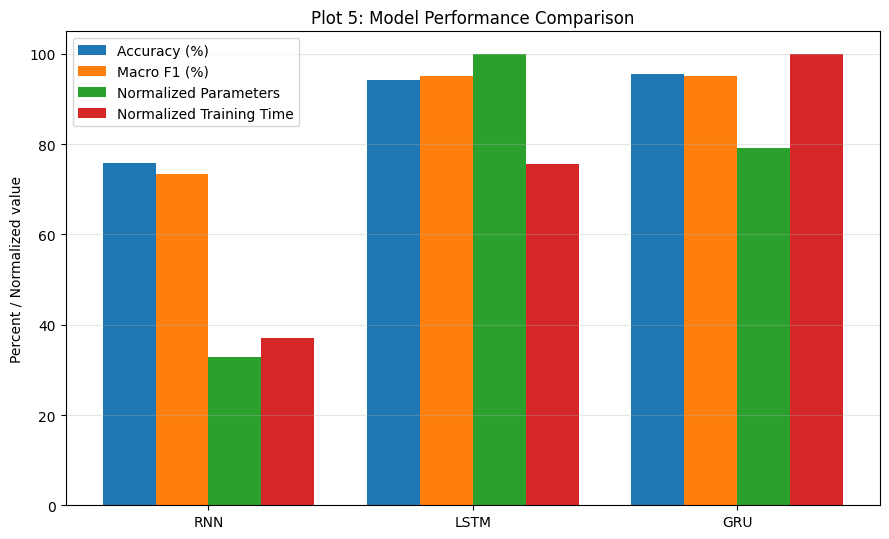

In [7]:
import numpy as np
import matplotlib.pyplot as plt

models = ["RNN", "LSTM", "GRU"]
accuracy = [75.78, 94.22, 95.56]
macro_f1 = [73.40, 95.13, 95.13]
parameters = [1974, 6006, 4758]
training_time = [52, 106, 140]

# Normalize params and time to 0-100 relative to the max, so they sit
# on the same axis as the accuracy/F1 percentages.
norm_params = [100 * p / max(parameters) for p in parameters]
norm_time = [100 * t / max(training_time) for t in training_time]

x = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.bar(x - 1.5 * width, accuracy, width, label="Accuracy (%)")
ax.bar(x - 0.5 * width, macro_f1, width, label="Macro F1 (%)")
ax.bar(x + 0.5 * width, norm_params, width, label="Normalized Parameters")
ax.bar(x + 1.5 * width, norm_time, width, label="Normalized Training Time")

ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel("Percent / Normalized value")
ax.set_title("Plot 5: Model Performance Comparison")
ax.legend()
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()
plt.savefig("plot5_model_comparison.png", dpi=150, bbox_inches="tight")
print("Saved plot5_model_comparison.png")
plt.show()


Sequence length T = 32
  RNN   T=32  Macro F1: 70.03%
  LSTM  T=32  Macro F1: 92.08%
  GRU   T=32  Macro F1: 93.38%

Sequence length T = 64
  RNN   T=64  Macro F1: 79.31%
  LSTM  T=64  Macro F1: 93.53%
  GRU   T=64  Macro F1: 94.94%

Sequence length T = 128
  RNN   T=128 Macro F1: 82.62%
  LSTM  T=128 Macro F1: 94.67%
  GRU   T=128 Macro F1: 94.65%

 Sequence Length  RNN F1  LSTM F1  GRU F1
              32   70.03    92.08   93.38
              64   79.31    93.53   94.94
             128   82.62    94.67   94.65

Saved plot6_seqlen_vs_f1.png


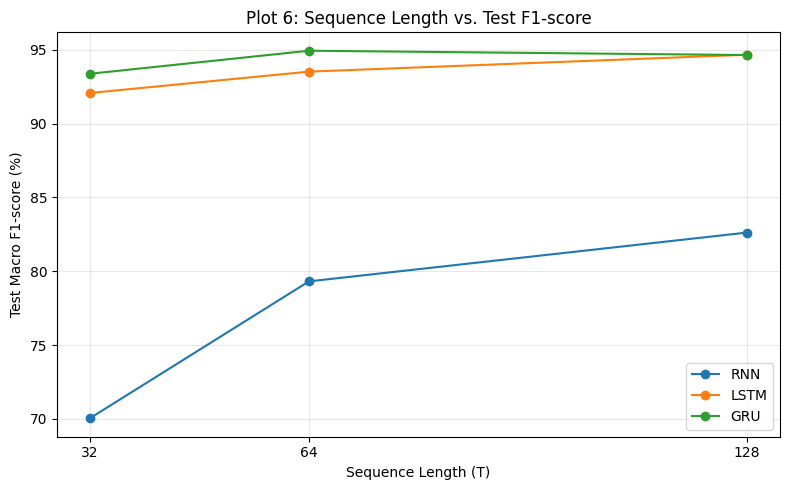

In [8]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from sklearn.metrics import precision_recall_fscore_support

N_FEATURES = 9
N_CLASSES = 6

RECURRENT_UNITS = 32
DROPOUT_RATE = 0.2
DENSE_UNITS = 16
LEARNING_RATE = 1e-3
BATCH_SIZE = 32
EPOCHS = 30
RANDOM_STATE = 42

SEQUENCE_LENGTHS = [32, 64, 128]


def truncate_sequences(X, T):
    """
    Construct a length-T input consistently by taking the first T time
    steps of each 128-step window. Applied identically to train/val/test
    and to every model, so comparisons across T are fair.
    """
    return X[:, :T, :]


def build_model(recurrent_type, time_steps):
    recurrent_type = recurrent_type.lower()
    if recurrent_type == "rnn":
        recurrent_layer = layers.SimpleRNN(RECURRENT_UNITS, name="rnn")
    elif recurrent_type == "lstm":
        recurrent_layer = layers.LSTM(RECURRENT_UNITS, name="lstm")
    elif recurrent_type == "gru":
        recurrent_layer = layers.GRU(RECURRENT_UNITS, name="gru")
    else:
        raise ValueError(f"Unknown recurrent_type: {recurrent_type}")

    model = models.Sequential([
        layers.Input(shape=(time_steps, N_FEATURES)),
        recurrent_layer,
        layers.Dropout(DROPOUT_RATE),
        layers.Dense(DENSE_UNITS, activation="relu", name="dense_hidden"),
        layers.Dense(N_CLASSES, activation="softmax", name="output"),
    ], name=f"{recurrent_type}_T{time_steps}")

    model.compile(
        optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def train_and_get_f1(recurrent_type, T, X_train, y_train, X_val, y_val, X_test, y_test):
    tf.random.set_seed(RANDOM_STATE)

    X_train_T = truncate_sequences(X_train, T)
    X_val_T = truncate_sequences(X_val, T)
    X_test_T = truncate_sequences(X_test, T)

    model = build_model(recurrent_type, T)
    model.fit(
        X_train_T, y_train,
        validation_data=(X_val_T, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0,
    )

    y_pred = np.argmax(model.predict(X_test_T, batch_size=BATCH_SIZE, verbose=0), axis=1)
    _, _, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="macro", zero_division=0)
    return f1 * 100


if __name__ == "__main__":
    # X_train, y_train, X_val, y_val, X_test, y_test already exist
    # (128-length, normalized) from the preprocessing step.
    results = {m: [] for m in ["rnn", "lstm", "gru"]}

    for T in SEQUENCE_LENGTHS:
        print(f"\n{'=' * 50}\nSequence length T = {T}\n{'=' * 50}")
        for recurrent_type in ["rnn", "lstm", "gru"]:
            f1 = train_and_get_f1(
                recurrent_type, T, X_train, y_train, X_val, y_val, X_test, y_test
            )
            results[recurrent_type].append(f1)
            print(f"  {recurrent_type.upper():<5s} T={T:<3d} Macro F1: {f1:.2f}%")

    # Table: Sequence Length | RNN F1 | LSTM F1 | GRU F1
    table = pd.DataFrame({
        "Sequence Length": SEQUENCE_LENGTHS,
        "RNN F1": results["rnn"],
        "LSTM F1": results["lstm"],
        "GRU F1": results["gru"],
    })
    print("\n" + table.round(2).to_string(index=False))

    # Plot 6: Sequence Length vs Test F1-score
    fig, ax = plt.subplots(figsize=(8, 5))
    for recurrent_type in ["rnn", "lstm", "gru"]:
        ax.plot(SEQUENCE_LENGTHS, results[recurrent_type], marker="o", label=recurrent_type.upper())
    ax.set_xlabel("Sequence Length (T)")
    ax.set_ylabel("Test Macro F1-score (%)")
    ax.set_title("Plot 6: Sequence Length vs. Test F1-score")
    ax.set_xticks(SEQUENCE_LENGTHS)
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.savefig("plot6_seqlen_vs_f1.png", dpi=150, bbox_inches="tight")
    print("\nSaved plot6_seqlen_vs_f1.png")
    plt.show()

**PART-2**

In [15]:
"""
Download a small, pre-made UCF101 subset from Hugging Face (~171 MB),
instead of the full ~6.5GB official archive or the now-403'd Google
Cloud Storage mirror.

pip install requests
"""

import os
import tarfile
import shutil
import urllib.request

HF_URL = "https://huggingface.co/datasets/sayakpaul/ucf101-subset/resolve/main/UCF101_subset.tar.gz"
DOWNLOAD_PATH = "data/UCF101_subset.tar.gz"
EXTRACT_DIR = "data/UCF101_subset_raw"
FINAL_DIR = "data/UCF101_subset"

# Available classes in this particular subset (only 10 total):
# ApplyEyeMakeup, ApplyLipstick, Archery, BabyCrawling, BalanceBeam,
# BandMarching, BaseballPitch, Basketball, BasketballDunk, BenchPress
SELECTED_CLASSES = ["Basketball", "BasketballDunk", "Archery", "BenchPress", "BabyCrawling"]


def download_ucf101_subset():
    os.makedirs("data", exist_ok=True)

    if not os.path.isfile(DOWNLOAD_PATH):
        print(f"Downloading {HF_URL} ...")
        urllib.request.urlretrieve(HF_URL, DOWNLOAD_PATH)
        print("Download complete.")
    else:
        print(f"'{DOWNLOAD_PATH}' already exists, skipping download.")

    already_extracted = os.path.isdir(EXTRACT_DIR) and len(os.listdir(EXTRACT_DIR)) > 0
    if not already_extracted:
        print("Extracting archive ...")
        os.makedirs(EXTRACT_DIR, exist_ok=True)
        with tarfile.open(DOWNLOAD_PATH, "r:*") as tar:  # auto-detect compression
            tar.extractall(EXTRACT_DIR)
        print("Extraction complete.")
    else:
        print(f"'{EXTRACT_DIR}' already has content, skipping extraction.")

    # This subset ships pre-split as UCF101_subset/{train,val,test}/<ClassName>/*.avi
    # (sometimes with an extra nested subfolder). Merge all splits per class
    # into a single flat folder per class, so it matches what the CNN+RNN
    # pipeline expects (our own script does the train/val/test split later,
    # on the extracted CNN features).
    os.makedirs(FINAL_DIR, exist_ok=True)
    root = None
    for dirpath, dirnames, filenames in os.walk(EXTRACT_DIR):
        if set(["train", "val", "test"]).intersection(dirnames):
            root = dirpath
            break
    if root is None:
        raise FileNotFoundError(
            f"Could not find train/val/test folders under '{EXTRACT_DIR}'. "
            f"Contents: {os.listdir(EXTRACT_DIR)}"
        )

    for split in ["train", "val", "test"]:
        split_dir = os.path.join(root, split)
        if not os.path.isdir(split_dir):
            continue
        for class_name in SELECTED_CLASSES:
            class_split_dir = os.path.join(split_dir, class_name)
            if not os.path.isdir(class_split_dir):
                continue

            class_final_dir = os.path.join(FINAL_DIR, class_name)
            os.makedirs(class_final_dir, exist_ok=True)
            # Walk recursively in case videos sit inside an extra nested
            # subfolder (e.g. .../Basketball/UCF101/*.avi).
            for dirpath, _, filenames in os.walk(class_split_dir):
                for fname in filenames:
                    if not fname.lower().endswith((".avi", ".mp4", ".mov")):
                        continue
                    src = os.path.join(dirpath, fname)
                    dst = os.path.join(class_final_dir, fname)
                    if not os.path.exists(dst):
                        shutil.copy2(src, dst)

    for class_name in SELECTED_CLASSES:
        class_dir = os.path.join(FINAL_DIR, class_name)
        count = len(os.listdir(class_dir)) if os.path.isdir(class_dir) else 0
        print(f"{class_name}: {count} videos")

    print(f"\nDone. Videos organized under: {FINAL_DIR}/<ClassName>/")


if __name__ == "__main__":
    download_ucf101_subset()

'data/UCF101_subset.tar.gz' already exists, skipping download.
'data/UCF101_subset_raw' already has content, skipping extraction.
Basketball: 44 videos
BasketballDunk: 39 videos
Archery: 40 videos
BenchPress: 42 videos
BabyCrawling: 42 videos

Done. Videos organized under: data/UCF101_subset/<ClassName>/


In [17]:
"""
Video Understanding using CNN + RNN (sections 18-19)
======================================================

Pipeline:
    Video -> Frame Extraction (10 uniform frames, 224x224x3)
          -> Pretrained CNN (MobileNetV2, feature extractor only)
          -> Frame Features (10, D)
          -> LSTM / GRU -> Dense(softmax) -> Action class

Expects videos already organized as:
    data/UCF101_subset/
        Basketball/*.avi
        BasketballDunk/*.avi
        Archery/*.avi
        BenchPress/*.avi
        BabyCrawling/*.avi

Requirements:
    pip install opencv-python tensorflow scikit-learn numpy
"""

import os
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import layers, models, optimizers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

# --------------------------------------------------------------------------- #
# Configuration
# --------------------------------------------------------------------------- #

DATASET_DIR = "data/UCF101_subset"
SELECTED_CLASSES = ["Basketball", "BasketballDunk", "Archery", "BenchPress", "BabyCrawling"]

NUM_FRAMES = 10
FRAME_SIZE = (224, 224)  # (width, height) for cv2.resize

RECURRENT_TYPE = "gru"   # "lstm" or "gru"
RECURRENT_UNITS = 32
DROPOUT_RATE = 0.2
LEARNING_RATE = 1e-3
BATCH_SIZE = 8
EPOCHS = 20
RANDOM_STATE = 42


# --------------------------------------------------------------------------- #
# Frame extraction
# --------------------------------------------------------------------------- #

def extract_frames(video_path, num_frames=NUM_FRAMES, size=FRAME_SIZE):
    """
    Sample num_frames uniformly across the video's length, resize each to
    `size`, and return an array of shape (num_frames, H, W, 3) in RGB.
    """
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames <= 0:
        cap.release()
        raise ValueError(f"Could not read frames from {video_path}")

    frame_indices = np.linspace(0, total_frames - 1, num_frames).astype(int)

    frames = []
    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ok, frame = cap.read()
        if not ok:
            frame = frames[-1] if frames else np.zeros((*size[::-1], 3), dtype=np.uint8)
        else:
            frame = cv2.resize(frame, size)
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame)
    cap.release()

    return np.stack(frames, axis=0)  # (num_frames, H, W, 3)


# --------------------------------------------------------------------------- #
# CNN feature extraction (MobileNetV2, frozen, no top)
# --------------------------------------------------------------------------- #

def build_feature_extractor():
    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        pooling="avg",
        input_shape=(224, 224, 3),
    )
    base_model.trainable = False
    return base_model


def extract_video_features(video_path, cnn_model):
    frames = extract_frames(video_path)                # (10, 224, 224, 3), RGB, uint8
    frames = frames.astype("float32")
    frames = preprocess_input(frames)
    features = cnn_model.predict(frames, verbose=0)     # (10, D)
    return features


# --------------------------------------------------------------------------- #
# Dataset construction
# --------------------------------------------------------------------------- #

def build_dataset(dataset_dir, selected_classes, cnn_model):
    X, y = [], []
    video_exts = (".avi", ".mp4", ".mov")

    for class_name in selected_classes:
        class_dir = os.path.join(dataset_dir, class_name)
        if not os.path.isdir(class_dir):
            print(f"  Warning: folder not found, skipping: {class_dir}")
            continue

        video_files = [f for f in os.listdir(class_dir) if f.lower().endswith(video_exts)]
        print(f"Processing '{class_name}': {len(video_files)} videos")

        for fname in video_files:
            video_path = os.path.join(class_dir, fname)
            try:
                features = extract_video_features(video_path, cnn_model)  # (10, D)
                X.append(features)
                y.append(class_name)
            except Exception as e:
                print(f"    Skipping {fname}: {e}")

    X = np.stack(X, axis=0)  # (N, 10, D)
    y = np.array(y)
    return X, y


# --------------------------------------------------------------------------- #
# Classifier: LSTM/GRU on frame-feature sequences
# --------------------------------------------------------------------------- #

def build_classifier(time_steps, feature_dim, n_classes, recurrent_type=RECURRENT_TYPE):
    recurrent_type = recurrent_type.lower()
    if recurrent_type == "lstm":
        recurrent_layer = layers.LSTM(RECURRENT_UNITS, name="lstm")
    elif recurrent_type == "gru":
        recurrent_layer = layers.GRU(RECURRENT_UNITS, name="gru")
    else:
        raise ValueError(f"Unknown recurrent_type: {recurrent_type}")

    model = models.Sequential([
        layers.Input(shape=(time_steps, feature_dim)),
        recurrent_layer,
        layers.Dropout(DROPOUT_RATE),
        layers.Dense(n_classes, activation="softmax", name="output"),
    ], name=f"video_{recurrent_type}_classifier")

    model.compile(
        optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


# --------------------------------------------------------------------------- #
# Main
# --------------------------------------------------------------------------- #

def main():
    tf.random.set_seed(RANDOM_STATE)
    np.random.seed(RANDOM_STATE)

    print("Building MobileNetV2 feature extractor (ImageNet weights, frozen)...")
    cnn_model = build_feature_extractor()
    feature_dim = cnn_model.output_shape[-1]
    print(f"Frame feature dimension D = {feature_dim}")

    print("\nExtracting CNN features from each video (this may take a while)...")
    X, y_raw = build_dataset(DATASET_DIR, SELECTED_CLASSES, cnn_model)
    print(f"\nDataset shape: X={X.shape}, y={y_raw.shape}")

    encoder = LabelEncoder()
    y = encoder.fit_transform(y_raw)
    class_names = list(encoder.classes_)
    n_classes = len(class_names)

    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, train_size=0.70, stratify=y, random_state=RANDOM_STATE
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, train_size=0.5, stratify=y_temp, random_state=RANDOM_STATE
    )
    print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

    classifier = build_classifier(NUM_FRAMES, feature_dim, n_classes)
    classifier.summary()

    history = classifier.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=2,
    )

    y_pred_probs = classifier.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="macro", zero_division=0
    )
    cm = confusion_matrix(y_test, y_pred)

    print(f"\nTest Accuracy: {accuracy*100:.2f}%")
    print(f"Macro Precision: {precision*100:.2f}%  Macro Recall: {recall*100:.2f}%  Macro F1: {f1*100:.2f}%")
    print("Confusion matrix (rows=true, cols=pred), class order:", class_names)
    print(cm)

    print("\nSample predictions:")
    for i in range(min(5, len(X_test))):
        probs = y_pred_probs[i]
        pred_idx = int(np.argmax(probs))
        confidence = float(probs[pred_idx])
        print(f"  Predicted class : {class_names[pred_idx]}")
        print(f"  Actual class    : {class_names[y_test[i]]}")
        print(f"  Confidence      : {confidence:.2f}\n")

    return {
        "classifier": classifier,
        "history": history.history,
        "class_names": class_names,
        "cnn_model": cnn_model,
        "y_test": y_test,
        "y_pred": y_pred,
        "confusion_matrix": cm,
    }


if __name__ == "__main__":
    results = main()

Building MobileNetV2 feature extractor (ImageNet weights, frozen)...
Frame feature dimension D = 1280

Extracting CNN features from each video (this may take a while)...
Processing 'Basketball': 44 videos
Processing 'BasketballDunk': 39 videos
Processing 'Archery': 40 videos
Processing 'BenchPress': 42 videos
Processing 'BabyCrawling': 42 videos

Dataset shape: X=(207, 10, 1280), y=(207,)
Train: (144, 10, 1280), Val: (31, 10, 1280), Test: (32, 10, 1280)


Model: "video_gru_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 32)             │       126,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,309 (493.39 KB)

 Trainable params: 126,309 (493.39 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
18/18 - 1s - 69ms/step - accuracy: 0.5139 - loss: 1.2366 - val_accuracy: 0.9355 - val_loss: 0.5313
Epoch 2/20
18/18 - 0s - 10ms/step - accuracy: 0.9583 - loss: 0.3574 - val_accuracy: 0.9677 - val_loss: 0.3094
Epoch 3/20
18/18 - 0s - 11ms/step - accuracy: 0.9861 - loss: 0.1792 - val_accuracy: 0.9677 - val_loss: 0.1518
Epoch 4/20
18/18 - 0s - 16ms/step - accuracy: 0.9931 - loss: 0.0938 - val_accuracy: 1.0000 - val_loss: 0.1137
Epoch 5/20
18/18 - 0s - 10ms/step - accuracy: 1.0000 - loss: 0.0672 - val_accuracy: 1.0000 - val_loss: 0.0876
Epoch 6/20
18/18 - 0s - 10ms/step - accuracy: 1.0000 - loss: 0.0463 - val_accuracy: 1.0000 - val_loss: 0.0836
Epoch 7/20
18/18 - 0s - 10ms/step - accuracy: 1.0000 - loss: 0.0377 - val_accuracy: 1.0000 - val_loss: 0.0690
Epoch 8/20
18/18 - 0s - 10ms/step - accuracy: 1.0000 - loss: 0.0317 - val_accuracy: 1.0000 - val_loss: 0.0600
Epoch 9/20
18/18 - 0s - 10ms/step - accuracy: 1.0000 - loss: 0.0342 - val_accuracy: 1.0000 - val_loss: 0.0567
Epoch 10/2

Saved plot7_sample_frames.png


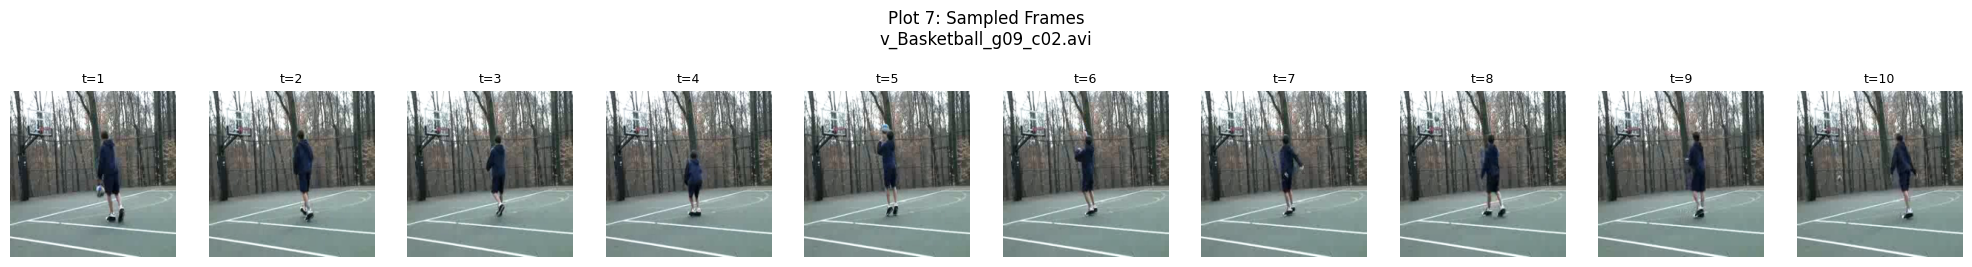

Saved plot8_video_training_curves.png


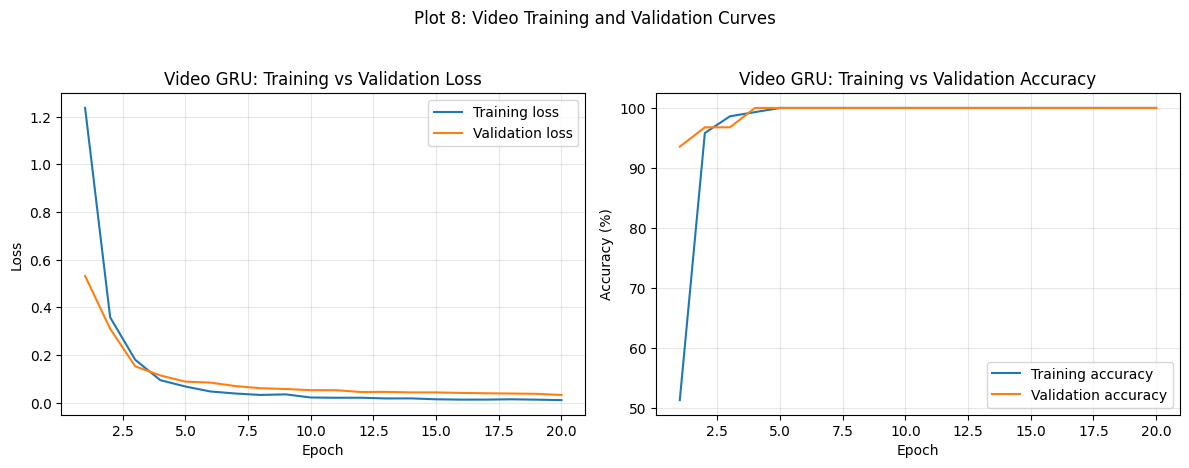

Saved plot9_video_confusion_matrix.png


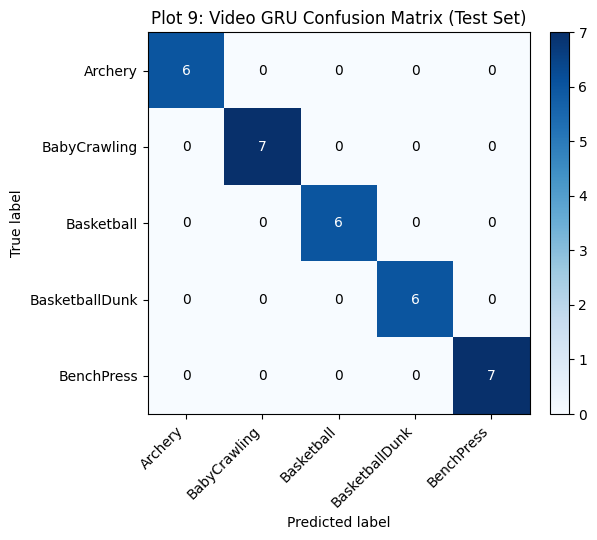

In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt

NUM_FRAMES = 10
FRAME_SIZE = (224, 224)


# --------------------------------------------------------------------------- #
# Plot 7: Video Sample Frames
# --------------------------------------------------------------------------- #

def plot_sample_frames(video_path, extract_frames_fn, num_frames=NUM_FRAMES):
    """
    Displays the num_frames sampled frames from one video in a single row,
    exactly as they're fed into the CNN.
    """
    frames = extract_frames_fn(video_path, num_frames=num_frames)  # (10, H, W, 3), RGB uint8

    fig, axes = plt.subplots(1, num_frames, figsize=(2 * num_frames, 2.5))
    for i, ax in enumerate(axes):
        ax.imshow(frames[i])
        ax.set_title(f"t={i+1}", fontsize=9)
        ax.axis("off")

    fig.suptitle(f"Plot 7: Sampled Frames\n{os.path.basename(video_path)}", y=1.05)
    fig.tight_layout()
    plt.savefig("plot7_sample_frames.png", dpi=150, bbox_inches="tight")
    print("Saved plot7_sample_frames.png")
    plt.show()


# --------------------------------------------------------------------------- #
# Plot 8: Video Training and Validation Curves
# --------------------------------------------------------------------------- #

def plot_video_training_curves(history, model_name="GRU"):
    epochs = range(1, len(history["loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    axes[0].plot(epochs, history["loss"], label="Training loss")
    axes[0].plot(epochs, history["val_loss"], label="Validation loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title(f"Video {model_name}: Training vs Validation Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    train_acc_pct = [a * 100 for a in history["accuracy"]]
    val_acc_pct = [a * 100 for a in history["val_accuracy"]]
    axes[1].plot(epochs, train_acc_pct, label="Training accuracy")
    axes[1].plot(epochs, val_acc_pct, label="Validation accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy (%)")
    axes[1].set_title(f"Video {model_name}: Training vs Validation Accuracy")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    fig.suptitle("Plot 8: Video Training and Validation Curves", y=1.03)
    fig.tight_layout()
    plt.savefig("plot8_video_training_curves.png", dpi=150, bbox_inches="tight")
    print("Saved plot8_video_training_curves.png")
    plt.show()


# --------------------------------------------------------------------------- #
# Plot 9: Video Confusion Matrix
# --------------------------------------------------------------------------- #

def plot_video_confusion_matrix(cm, class_names, model_name="GRU"):
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(f"Plot 9: Video {model_name} Confusion Matrix (Test Set)")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black")

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    plt.savefig("plot9_video_confusion_matrix.png", dpi=150, bbox_inches="tight")
    print("Saved plot9_video_confusion_matrix.png")
    plt.show()


if __name__ == "__main__":
    # Plot 7: one sample video from any class
    sample_video_path = "data/UCF101_subset/Basketball/" + os.listdir("data/UCF101_subset/Basketball")[0]
    plot_sample_frames(sample_video_path, extract_frames)

    # Plot 8
    plot_video_training_curves(results["history"], model_name="GRU")

    # Plot 9
    plot_video_confusion_matrix(results["confusion_matrix"], results["class_names"], model_name="GRU")

Dataset: X=(5000, 4), y=(5000, 4)
Example: [0, 7, 6, 4] -> [4, 6, 7, 0]
Train: (3500, 4), Val: (750, 4), Test: (750, 4)


Model: "seq2seq_reversal"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_sequence      │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 4, 32)     │        320 │ input_sequence[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 64),      │     24,832 │ embedding[0][0]   │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ context_state       │ (None, 4, 64)     │          0 │ encoder_lstm[0][… │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ (None, 4, 64)     │     33,024 │ context_state[0]… │
│                     │                   │            │ encoder_lstm[0][… │
│                     │                   │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_sequence     │ (None, 4, 10)     │        650 │ decoder_lstm[0][… │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 58,826 (229.79 KB)

 Trainable params: 58,826 (229.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
55/55 - 5s - 89ms/step - accuracy: 0.3128 - loss: 2.1305 - val_accuracy: 0.3373 - val_loss: 1.7902
Epoch 2/30
55/55 - 1s - 14ms/step - accuracy: 0.3803 - loss: 1.6112 - val_accuracy: 0.3950 - val_loss: 1.4861
Epoch 3/30
55/55 - 1s - 15ms/step - accuracy: 0.4172 - loss: 1.3497 - val_accuracy: 0.4423 - val_loss: 1.2433
Epoch 4/30
55/55 - 1s - 12ms/step - accuracy: 0.5086 - loss: 1.0974 - val_accuracy: 0.5757 - val_loss: 0.9721
Epoch 5/30
55/55 - 1s - 9ms/step - accuracy: 0.6424 - loss: 0.8491 - val_accuracy: 0.6743 - val_loss: 0.7704
Epoch 6/30
55/55 - 1s - 9ms/step - accuracy: 0.7202 - loss: 0.6861 - val_accuracy: 0.7413 - val_loss: 0.6379
Epoch 7/30
55/55 - 1s - 9ms/step - accuracy: 0.7841 - loss: 0.5695 - val_accuracy: 0.7950 - val_loss: 0.5429
Epoch 8/30
55/55 - 1s - 9ms/step - accuracy: 0.8401 - loss: 0.4717 - val_accuracy: 0.8397 - val_loss: 0.4569
Epoch 9/30
55/55 - 1s - 9ms/step - accuracy: 0.8855 - loss: 0.3826 - val_accuracy: 0.8747 - val_loss: 0.3752
Epoch 10/30
55/

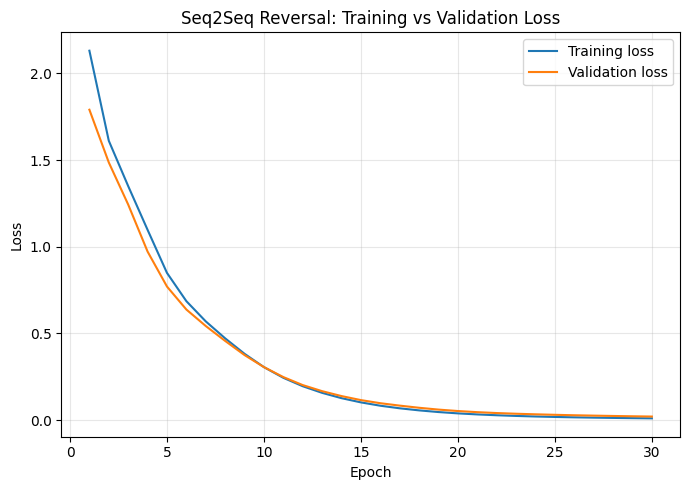

In [19]:
"""
Sequence-to-Sequence Learning: Reversal Task (sections 22-24)
================================================================

Pipeline:
    Input Sequence -> Encoder LSTM -> Context State
                    -> Decoder LSTM -> Output Sequence

Task: reverse a sequence of integers, e.g. [3, 8, 1, 5] -> [5, 1, 8, 3]
"""

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from sklearn.model_selection import train_test_split

# --------------------------------------------------------------------------- #
# Configuration
# --------------------------------------------------------------------------- #

VOCAB_SIZE = 10        # integers 0-9
SEQ_LEN = 4             # fixed sequence length
NUM_SAMPLES = 5000      # "several thousand" sequences

EMBEDDING_DIM = 32
LSTM_UNITS = 64
LEARNING_RATE = 1e-3
BATCH_SIZE = 64
EPOCHS = 30
RANDOM_STATE = 42


# --------------------------------------------------------------------------- #
# Synthetic reversal dataset
# --------------------------------------------------------------------------- #

def generate_reversal_dataset(num_samples=NUM_SAMPLES, seq_len=SEQ_LEN,
                               vocab_size=VOCAB_SIZE, random_state=RANDOM_STATE):
    """
    Generates num_samples random integer sequences of length seq_len,
    drawn from [0, vocab_size), and their reversed counterparts.
    Returns X, y both of shape (num_samples, seq_len).
    """
    rng = np.random.default_rng(random_state)
    X = rng.integers(0, vocab_size, size=(num_samples, seq_len))
    y = X[:, ::-1].copy()  # reversed sequence is the target
    return X, y


# --------------------------------------------------------------------------- #
# Encoder-Decoder LSTM model
# --------------------------------------------------------------------------- #

def build_seq2seq_model(seq_len=SEQ_LEN, vocab_size=VOCAB_SIZE,
                         embedding_dim=EMBEDDING_DIM, lstm_units=LSTM_UNITS):
    """
    Input Sequence -> Embedding -> Encoder LSTM -> Context State
                   -> RepeatVector -> Decoder LSTM -> Dense(softmax) per step
                   -> Output Sequence

    Since input and output length are equal here (pure reversal), the
    context vector is repeated seq_len times to drive a fixed-length decoder
    (a common simplification of the general encoder-decoder pattern for
    fixed-length seq2seq tasks).
    """
    inputs = layers.Input(shape=(seq_len,), name="input_sequence")
    x = layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim, name="embedding")(inputs)

    # Encoder: compresses the input sequence into a single context vector
    _, state_h, state_c = layers.LSTM(lstm_units, return_state=True, name="encoder_lstm")(x)
    context = state_h  # the learned representation of the whole input sequence

    # Decoder: generates the output sequence one element at a time from the context
    decoder_input = layers.RepeatVector(seq_len, name="context_state")(context)
    decoder_lstm_out = layers.LSTM(lstm_units, return_sequences=True, name="decoder_lstm")(
        decoder_input, initial_state=[state_h, state_c]
    )
    outputs = layers.TimeDistributed(
        layers.Dense(vocab_size, activation="softmax"), name="output_sequence"
    )(decoder_lstm_out)

    model = models.Model(inputs, outputs, name="seq2seq_reversal")
    model.compile(
        optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],  # this reports per-token (per-timestep) accuracy
    )
    return model


# --------------------------------------------------------------------------- #
# Evaluation metrics
# --------------------------------------------------------------------------- #

def token_accuracy(y_true, y_pred):
    """Fraction of individual positions predicted correctly, across all sequences."""
    return float(np.mean(y_true == y_pred))


def sequence_accuracy(y_true, y_pred):
    """Fraction of sequences where EVERY position was predicted correctly."""
    return float(np.mean(np.all(y_true == y_pred, axis=1)))


# --------------------------------------------------------------------------- #
# Main
# --------------------------------------------------------------------------- #

def main():
    tf.random.set_seed(RANDOM_STATE)
    np.random.seed(RANDOM_STATE)

    X, y = generate_reversal_dataset()
    print(f"Dataset: X={X.shape}, y={y.shape}")
    print(f"Example: {X[0].tolist()} -> {y[0].tolist()}")

    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, train_size=0.70, random_state=RANDOM_STATE
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, train_size=0.5, random_state=RANDOM_STATE
    )
    print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

    model = build_seq2seq_model()
    model.summary()

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=2,
    )

    # Predict on test set
    y_pred_probs = model.predict(X_test, verbose=0)          # (N, seq_len, vocab_size)
    y_pred = np.argmax(y_pred_probs, axis=-1)                 # (N, seq_len)

    tok_acc = token_accuracy(y_test, y_pred)
    seq_acc = sequence_accuracy(y_test, y_pred)
    final_train_loss = history.history["loss"][-1]
    final_val_loss = history.history["val_loss"][-1]

    print(f"\nToken Accuracy    : {tok_acc*100:.2f}%")
    print(f"Sequence Accuracy : {seq_acc*100:.2f}%")
    print(f"Final Training Loss   : {final_train_loss:.4f}")
    print(f"Final Validation Loss : {final_val_loss:.4f}")

    # Required: display at least 5 test examples
    print("\nSample | Input Sequence      | Predicted Output")
    print("-" * 55)
    for i in range(5):
        print(f"{i+1:<7}| {X_test[i].tolist()!s:<20} | {y_pred[i].tolist()}")

    # Training/validation loss curves
    epochs_range = range(1, EPOCHS + 1)
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(epochs_range, history.history["loss"], label="Training loss")
    ax.plot(epochs_range, history.history["val_loss"], label="Validation loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title("Seq2Seq Reversal: Training vs Validation Loss")
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.savefig("seq2seq_loss_curve.png", dpi=150, bbox_inches="tight")
    print("\nSaved seq2seq_loss_curve.png")
    plt.show()

    return {
        "model": model,
        "history": history.history,
        "token_accuracy": tok_acc,
        "sequence_accuracy": seq_acc,
        "X_test": X_test,
        "y_test": y_test,
        "y_pred": y_pred,
    }


if __name__ == "__main__":
    results = main()